In [2]:
import pickle
import os
import torch
import contextlib
import numpy as np
import json
import yolo_patch_sigmoid
import math
import numpy as np
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import skimage.io as io
from ultralytics import YOLO 
from dotenv import load_dotenv
from tqdm import tqdm  # For progress tracking
import time
load_dotenv()  # This loads from .env in the current directory

True

In [3]:
def compute_iou(box1, box2):
    """
    Computes IoU between two bounding boxes.
    box format: [x1, y1, x2, y2]
    """

    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    # Compute the area of intersection rectangle
    inter_width = max(0, x2_inter - x1_inter)
    inter_height = max(0, y2_inter - y1_inter)
    inter_area = inter_width * inter_height

    # Compute the area of both bounding boxes
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Compute the IoU
    union_area = box1_area + box2_area - inter_area
    iou = inter_area / union_area if union_area > 0 else 0

    return iou

def bin_index(scale, bin_vector):
    """
    Computes the bin index for a given scale and bin vector.
    """
    bin_index = -1
    for i in range(len(bin_vector)):
        if scale <= bin_vector[i] or scale > bin_vector[-1]:
            break
        bin_index += 1

    if bin_index == -1: bin_index = 0

    return bin_index

In [4]:
# === Load YOLO model ===
yolo_model = YOLO("yolo11x.pt")  # Swap with yolov8s.pt or yolov8x.pt as needed

In [5]:
# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
yolo_model = yolo_model.to(device)

Using device: cuda:0


In [6]:
# Load annotations for both datasets
cocos = {
    "train2017": COCO(os.path.join(os.getenv("COCO_DATA"), "annotations/instances_train2017.json")),
    "val2017": COCO(os.path.join(os.getenv("COCO_DATA"), "annotations/instances_val2017.json")),
}

loading annotations into memory...
Done (t=16.98s)
creating index...
index created!
loading annotations into memory...
Done (t=0.62s)
creating index...
index created!


In [8]:
# YOLO ID -- Class mapping from json file
with open('indoor_objects.json') as f:
    indoor_objects = json.load(f)
    indoor_objects = {k: v for d in indoor_objects['indoor_classes'] for k, v in d.items()}

# Bin range -- Class from json file
with open("bins_per_obj_class.json") as f:
    out_bins_per_class = json.load(f)

# YOLO IDs -- COCO IDs mapping
train_coco = list(cocos.values())[0]
all_cats = train_coco.loadCats(train_coco.getCatIds())
yolo_id_to_coco_id = {i: cat["id"] for i, cat in enumerate(sorted(all_cats, key=lambda x: x["id"]))} # eg. Yolo ID 79 -> COCO ID 90

# Build lists 
yolo_ids = [int(k) for k in indoor_objects.keys()]
coco_ids = [yolo_id_to_coco_id[int(k)] for k in indoor_objects.keys()]
classes_names = [v for v in indoor_objects.values()]
classes_bins = [out_bins_per_class[v] for v in indoor_objects.values()]
num_classes = len(classes_bins)

# Print information
print("Number of classes:", num_classes,'\n')
print("YOLO IDs:", yolo_ids)
print("COCO IDs:", coco_ids)
print("Classes names:", classes_names)
print("Classes bins:", classes_bins)


Number of classes: 27 

YOLO IDs: [26, 39, 40, 41, 42, 43, 44, 45, 47, 56, 57, 58, 59, 60, 61, 62, 63, 65, 67, 68, 69, 70, 71, 73, 74, 75, 77]
COCO IDs: [31, 44, 46, 47, 48, 49, 50, 51, 53, 62, 63, 64, 65, 67, 70, 72, 73, 75, 77, 78, 79, 80, 81, 84, 85, 86, 88]
Classes names: ['handbag', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'apple', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'remote', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'book', 'clock', 'vase', 'teddy bear']
Classes bins: [[0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4], [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01], [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2], [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0], [0.0, 0.11, 0.23, 0.4, 0.62, 0.99, 1.64, 2.71, 4.88, 9.2, 99.45], [0.0, 0.04, 0.09, 0.17, 0.3, 0.55, 0.94, 1.59, 3.0, 6.7, 83.22], [0.0, 0.06, 0.12, 0.21, 0.34, 0.54, 

In [9]:
# === Helper: Get COCO split for a given image ID ===
def find_split_for_image(img_id):
    for split, coco_obj in cocos.items():
        if img_id in coco_obj.imgs:
            return split, coco_obj
    return None, None

Processing 118287 images in train2017:   0%|          | 0/118287 [00:00<?, ?image/s]

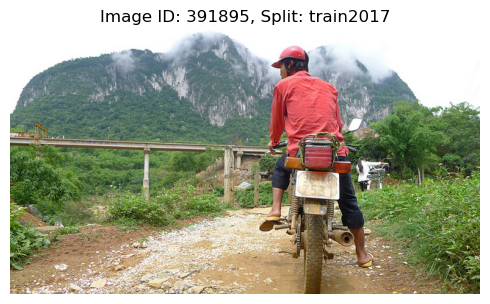

Processing 118287 images in train2017:   0%|          | 1/118287 [00:00<7:31:01,  4.37image/s]



****DETECTED CLASS NAME: knife****
Confidence: 0.9993, Class ID: 43

GROUND TRUTH CLASS NAME: knife
Correct detection in bin 9 for class knife
9 [0 0 0 0 0 0 0 0 0 1] [0 0 0 0 0 0 0 0 0 1]


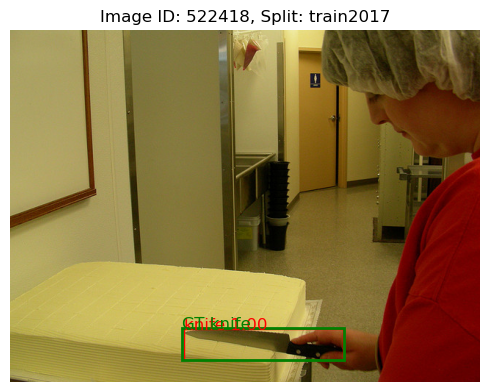

Processing 118287 images in train2017:   0%|          | 2/118287 [00:00<8:13:15,  4.00image/s]

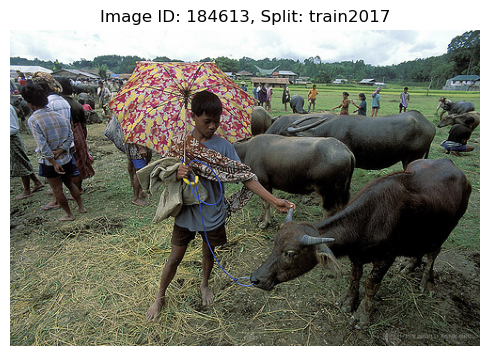

Processing 118287 images in train2017:   0%|          | 3/118287 [00:00<7:33:19,  4.35image/s]



****DETECTED CLASS NAME: tv****
Confidence: 0.9986, Class ID: 62

GROUND TRUTH CLASS NAME: tv
Correct detection in bin 9 for class tv
9 [0 0 0 0 0 0 0 0 0 2] [0 0 0 0 0 0 0 0 0 2]


****DETECTED CLASS NAME: tv****
Confidence: 0.9986, Class ID: 62

GROUND TRUTH CLASS NAME: tv
Correct detection in bin 9 for class tv
9 [0 0 0 0 0 0 0 0 0 3] [0 0 0 0 0 0 0 0 0 3]


****DETECTED CLASS NAME: tv****
Confidence: 0.9986, Class ID: 62

GROUND TRUTH CLASS NAME: tv
Correct detection in bin 9 for class tv
9 [0 0 0 0 0 0 0 0 0 4] [0 0 0 0 0 0 0 0 0 4]


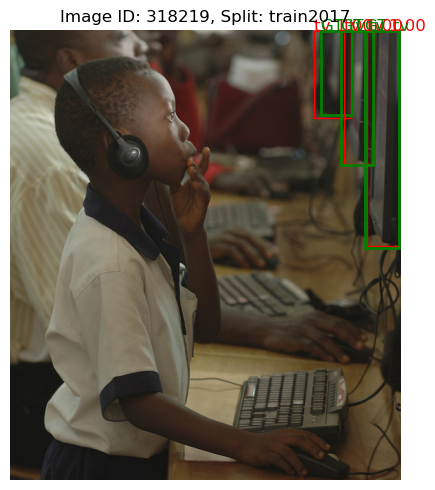

Processing 118287 images in train2017:   0%|          | 4/118287 [00:01<8:44:56,  3.76image/s]



****DETECTED CLASS NAME: tv****
Confidence: 0.9976, Class ID: 62

GROUND TRUTH CLASS NAME: tv
Correct detection in bin 9 for class tv
9 [0 0 0 0 0 0 0 0 0 5] [0 0 0 0 0 0 0 0 0 5]


****DETECTED CLASS NAME: tv****
Confidence: 0.9932, Class ID: 62

GROUND TRUTH CLASS NAME: tv
Correct detection in bin 9 for class tv
9 [0 0 0 0 0 0 0 0 0 6] [0 0 0 0 0 0 0 0 0 6]


****DETECTED CLASS NAME: tv****
Confidence: 0.9915, Class ID: 62

GROUND TRUTH CLASS NAME: tv
Correct detection in bin 9 for class tv
9 [0 0 0 0 0 0 0 0 0 7] [0 0 0 0 0 0 0 0 0 7]


****DETECTED CLASS NAME: tv****
Confidence: 0.9915, Class ID: 62

GROUND TRUTH CLASS NAME: tv
Correct detection in bin 9 for class tv
9 [0 0 0 0 0 0 0 0 0 8] [0 0 0 0 0 0 0 0 0 8]


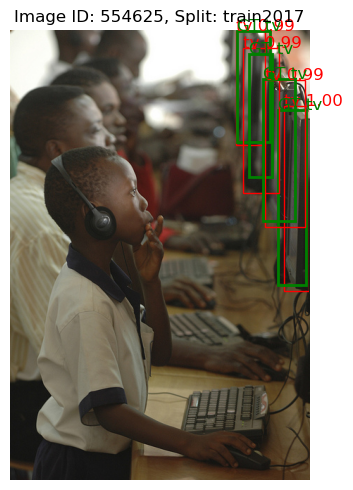

Processing 118287 images in train2017:   0%|          | 5/118287 [00:01<8:29:24,  3.87image/s]



****DETECTED CLASS NAME: clock****
Confidence: 0.9999, Class ID: 74

GROUND TRUTH CLASS NAME: clock
Correct detection in bin 9 for class clock
9 [0 0 0 0 0 0 0 0 0 9] [0 0 0 0 0 0 0 0 0 9]


****DETECTED CLASS NAME: potted plant****
Confidence: 0.9998, Class ID: 58

GROUND TRUTH CLASS NAME: potted plant
Correct detection in bin 9 for class potted plant
9 [ 0  0  0  0  0  0  0  0  0 10] [ 0  0  0  0  0  0  0  0  0 10]


****DETECTED CLASS NAME: handbag****
Confidence: 0.9998, Class ID: 26

GROUND TRUTH CLASS NAME: handbag
Correct detection in bin 9 for class handbag
9 [ 0  0  0  0  0  0  0  0  0 11] [ 0  0  0  0  0  0  0  0  0 11]


****DETECTED CLASS NAME: bottle****
Confidence: 0.9997, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  0  0  0 12] [ 0  0  0  0  0  0  0  0  0 12]


****DETECTED CLASS NAME: sink****
Confidence: 0.9994, Class ID: 71

GROUND TRUTH CLASS NAME: sink
Correct detection in bin 9 for class sink
9 [ 

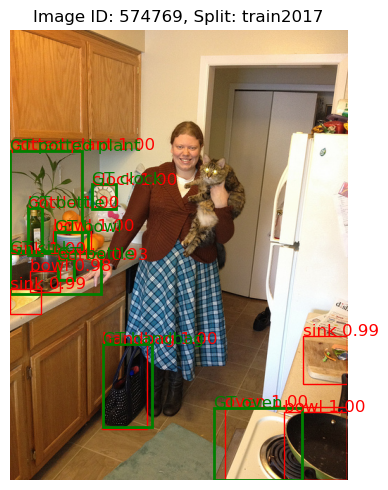

Processing 118287 images in train2017:   0%|          | 6/118287 [00:01<8:57:33,  3.67image/s]



****DETECTED CLASS NAME: bowl****
Confidence: 0.9997, Class ID: 45

GROUND TRUTH CLASS NAME: bowl
Correct detection in bin 9 for class bowl
9 [ 0  0  0  0  0  0  0  0  0 21] [ 0  0  0  0  0  0  0  0  0 17]


****DETECTED CLASS NAME: dining table****
Confidence: 0.9988, Class ID: 60

GROUND TRUTH CLASS NAME: dining table
Correct detection in bin 9 for class dining table
9 [ 0  0  0  0  0  0  0  0  0 22] [ 0  0  0  0  0  0  0  0  0 18]


****DETECTED CLASS NAME: spoon****
Confidence: 0.9987, Class ID: 44

GROUND TRUTH CLASS NAME: spoon
Correct detection in bin 9 for class spoon
9 [ 0  0  0  0  0  0  0  0  0 23] [ 0  0  0  0  0  0  0  0  0 19]


****DETECTED CLASS NAME: wine glass****
Confidence: 0.9983, Class ID: 40

GROUND TRUTH CLASS NAME: wine glass
Correct detection in bin 9 for class wine glass
9 [ 0  0  0  0  0  0  0  0  0 24] [ 0  0  0  0  0  0  0  0  0 20]


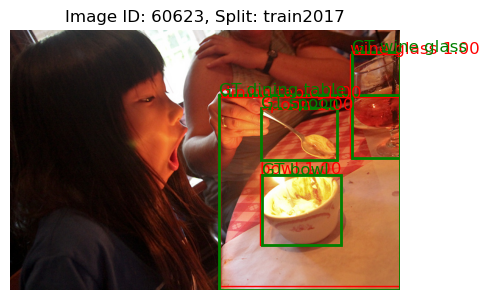

Processing 118287 images in train2017:   0%|          | 7/118287 [00:01<8:33:29,  3.84image/s]



****DETECTED CLASS NAME: bottle****
Confidence: 0.9998, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  0  0  0 25] [ 0  0  0  0  0  0  0  0  0 21]


****DETECTED CLASS NAME: bottle****
Confidence: 0.9998, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  0  0  0 26] [ 0  0  0  0  0  0  0  0  0 22]


****DETECTED CLASS NAME: bottle****
Confidence: 0.9996, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  0  0  0 27] [ 0  0  0  0  0  0  0  0  0 23]


****DETECTED CLASS NAME: bowl****
Confidence: 0.9990, Class ID: 45


****DETECTED CLASS NAME: sink****
Confidence: 0.9980, Class ID: 71


****DETECTED CLASS NAME: oven****
Confidence: 0.8441, Class ID: 69

GROUND TRUTH CLASS NAME: oven
Correct detection in bin 8 for class oven
8 [ 0  0  0  0  0  0  0  0  1 29] [ 0  0  0  0  0  0  0  0  1 23]


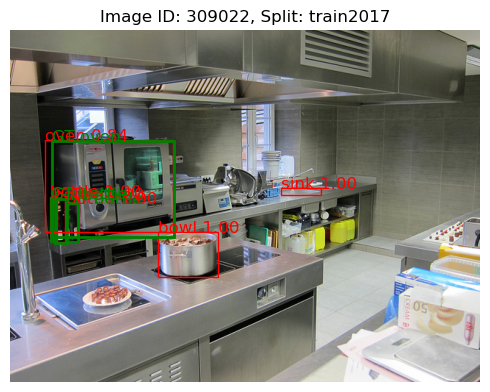

Processing 118287 images in train2017:   0%|          | 8/118287 [00:02<9:14:10,  3.56image/s]



****DETECTED CLASS NAME: bottle****
Confidence: 0.9998, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  0  0  1 30] [ 0  0  0  0  0  0  0  0  1 24]


****DETECTED CLASS NAME: bottle****
Confidence: 0.9997, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  0  0  1 31] [ 0  0  0  0  0  0  0  0  1 25]


****DETECTED CLASS NAME: bottle****
Confidence: 0.9997, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  0  0  1 32] [ 0  0  0  0  0  0  0  0  1 26]


****DETECTED CLASS NAME: bottle****
Confidence: 0.9992, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  0  0  1 33] [ 0  0  0  0  0  0  0  0  1 27]


****DETECTED CLASS NAME: bottle****
Confidence: 0.9988, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bot

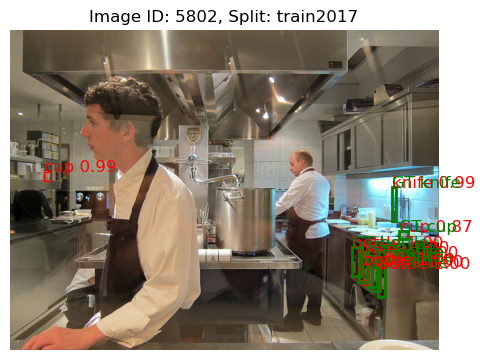

Processing 118287 images in train2017:   0%|          | 9/118287 [00:02<9:44:59,  3.37image/s]



****DETECTED CLASS NAME: bottle****
Confidence: 0.9995, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  0  0  2 38] [ 0  0  0  0  0  0  0  0  2 30]


****DETECTED CLASS NAME: oven****
Confidence: 0.9989, Class ID: 69

GROUND TRUTH CLASS NAME: oven
Correct detection in bin 9 for class oven
9 [ 0  0  0  0  0  0  0  0  2 39] [ 0  0  0  0  0  0  0  0  2 31]


****DETECTED CLASS NAME: microwave****
Confidence: 0.7627, Class ID: 68

GROUND TRUTH CLASS NAME: microwave
Correct detection in bin 7 for class microwave
7 [ 0  0  0  0  0  0  0  1  2 39] [ 0  0  0  0  0  0  0  1  2 31]


****DETECTED CLASS NAME: oven****
Confidence: 0.6018, Class ID: 69


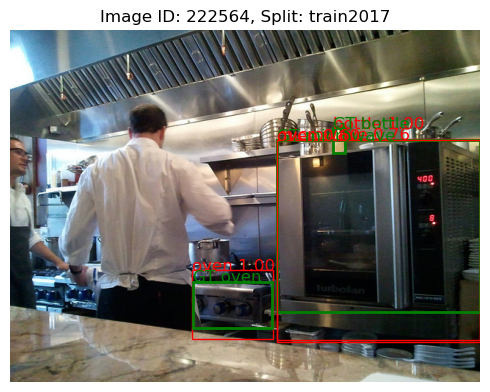

Processing 118287 images in train2017:   0%|          | 10/118287 [00:02<9:41:38,  3.39image/s]



****DETECTED CLASS NAME: bottle****
Confidence: 0.9985, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  1  1  2 40] [ 0  0  0  0  0  0  0  1  2 32]


****DETECTED CLASS NAME: bowl****
Confidence: 0.9974, Class ID: 45


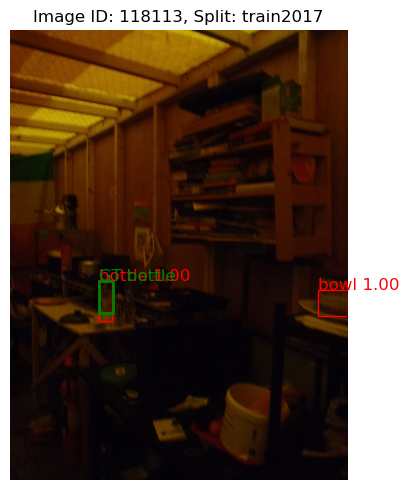

Processing 118287 images in train2017:   0%|          | 11/118287 [00:02<9:14:36,  3.55image/s]



****DETECTED CLASS NAME: oven****
Confidence: 0.9993, Class ID: 69

GROUND TRUTH CLASS NAME: oven
Correct detection in bin 9 for class oven
9 [ 0  0  0  0  0  0  1  1  2 42] [ 0  0  0  0  0  0  0  1  2 33]


****DETECTED CLASS NAME: bottle****
Confidence: 0.9988, Class ID: 39

GROUND TRUTH CLASS NAME: bottle
Correct detection in bin 9 for class bottle
9 [ 0  0  0  0  0  0  1  1  2 43] [ 0  0  0  0  0  0  0  1  2 34]


****DETECTED CLASS NAME: sink****
Confidence: 0.9985, Class ID: 71

GROUND TRUTH CLASS NAME: sink
Correct detection in bin 9 for class sink
9 [ 0  0  0  0  0  0  1  1  2 44] [ 0  0  0  0  0  0  0  1  2 35]


****DETECTED CLASS NAME: bottle****
Confidence: 0.9976, Class ID: 39


****DETECTED CLASS NAME: spoon****
Confidence: 0.9971, Class ID: 44

GROUND TRUTH CLASS NAME: spoon
Correct detection in bin 9 for class spoon
9 [ 0  0  0  0  0  0  1  1  2 46] [ 0  0  0  0  0  0  0  1  2 36]


****DETECTED CLASS NAME: bottle****
Confidence: 0.9967, Class ID: 39

GROUND TRUTH CLA

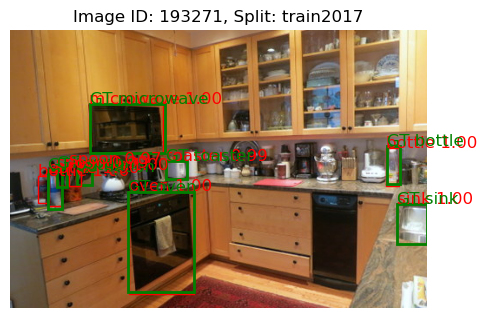

Processing 118287 images in train2017:   0%|          | 12/118287 [00:03<9:17:49,  3.53image/s]



****DETECTED CLASS NAME: toilet****
Confidence: 0.9982, Class ID: 61

GROUND TRUTH CLASS NAME: toilet
Correct detection in bin 9 for class toilet
9 [ 0  0  0  0  0  0  1  1  2 52] [ 0  0  0  0  0  0  0  1  2 41]


****DETECTED CLASS NAME: sink****
Confidence: 0.9979, Class ID: 71


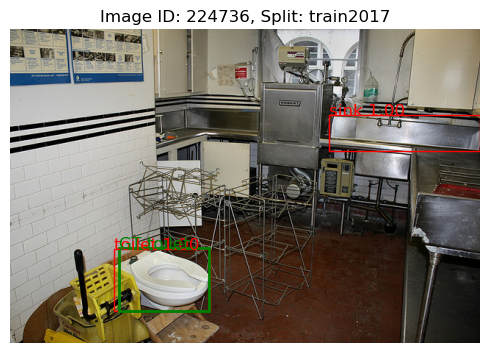

Processing 118287 images in train2017:   0%|          | 13/118287 [00:03<8:52:00,  3.71image/s]

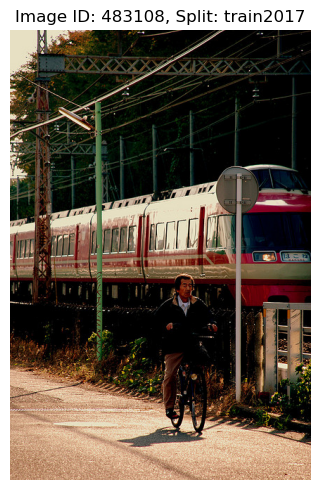

Processing 118287 images in train2017:   0%|          | 14/118287 [00:03<8:56:31,  3.67image/s]



****DETECTED CLASS NAME: sink****
Confidence: 0.9997, Class ID: 71

GROUND TRUTH CLASS NAME: sink
Correct detection in bin 9 for class sink
9 [ 0  0  0  0  0  0  1  1  2 54] [ 0  0  0  0  0  0  0  1  2 42]


****DETECTED CLASS NAME: oven****
Confidence: 0.9995, Class ID: 69

GROUND TRUTH CLASS NAME: oven
Correct detection in bin 9 for class oven
9 [ 0  0  0  0  0  0  1  1  2 55] [ 0  0  0  0  0  0  0  1  2 43]


****DETECTED CLASS NAME: microwave****
Confidence: 0.9956, Class ID: 68

GROUND TRUTH CLASS NAME: microwave
Correct detection in bin 9 for class microwave
9 [ 0  0  0  0  0  0  1  1  2 56] [ 0  0  0  0  0  0  0  1  2 44]


****DETECTED CLASS NAME: bowl****
Confidence: 0.9917, Class ID: 45

GROUND TRUTH CLASS NAME: bowl
Correct detection in bin 9 for class bowl
9 [ 0  0  0  0  0  0  1  1  2 57] [ 0  0  0  0  0  0  0  1  2 45]


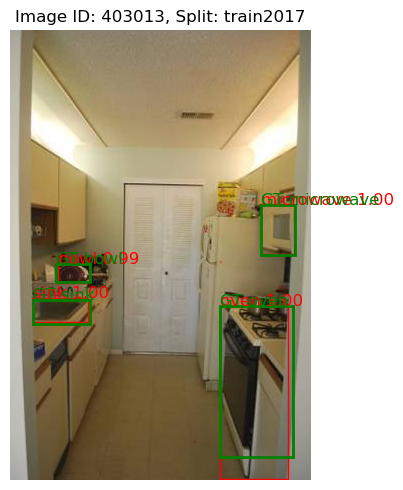

Processing 118287 images in train2017:   0%|          | 15/118287 [00:04<8:23:59,  3.91image/s]



****DETECTED CLASS NAME: chair****
Confidence: 0.9998, Class ID: 56

GROUND TRUTH CLASS NAME: chair
Correct detection in bin 9 for class chair
9 [ 0  0  0  0  0  0  1  1  2 58] [ 0  0  0  0  0  0  0  1  2 46]


****DETECTED CLASS NAME: dining table****
Confidence: 0.9998, Class ID: 60

GROUND TRUTH CLASS NAME: dining table
Correct detection in bin 9 for class dining table
9 [ 0  0  0  0  0  0  1  1  2 59] [ 0  0  0  0  0  0  0  1  2 47]


****DETECTED CLASS NAME: chair****
Confidence: 0.9997, Class ID: 56

GROUND TRUTH CLASS NAME: chair
Correct detection in bin 9 for class chair
9 [ 0  0  0  0  0  0  1  1  2 60] [ 0  0  0  0  0  0  0  1  2 48]


****DETECTED CLASS NAME: chair****
Confidence: 0.9997, Class ID: 56

GROUND TRUTH CLASS NAME: chair
Correct detection in bin 9 for class chair
9 [ 0  0  0  0  0  0  1  1  2 61] [ 0  0  0  0  0  0  0  1  2 49]


****DETECTED CLASS NAME: laptop****
Confidence: 0.9996, Class ID: 63

GROUND TRUTH CLASS NAME: laptop
Correct detection in bin 9 for 

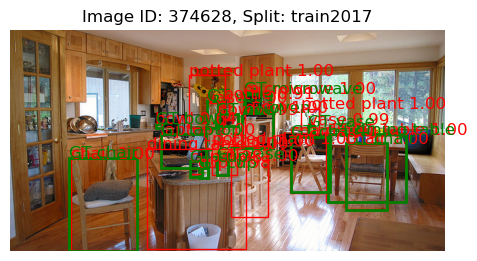

Processing 118287 images in train2017:   0%|          | 16/118287 [00:04<9:07:16,  3.60image/s]


KeyboardInterrupt: 

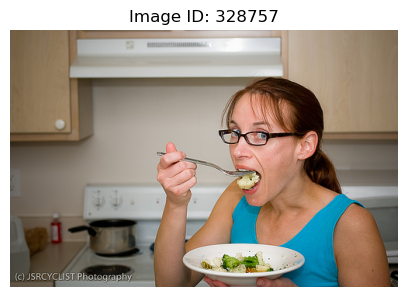

In [21]:
# === IoU threshold for filtering ===
IOU_THRESHOLD = 0.5

# === Data structure to store the counting of classes in bins ===
bins = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
total_counter = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
correct_counter = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Loop through every image in the dataset
for split, coco_obj in cocos.items():
    
    # Get all image IDs
    img_ids = coco_obj.getImgIds()
    
    # Loop through each image ID
    for img_id in tqdm(img_ids, desc=f"Processing {len(img_ids)} images in {split}", unit="image"):
        
        # Load the image 
        img_data = coco_obj.imgs[img_id]
        img_path = os.path.join(os.getenv("COCO_DATA"), split, img_data["file_name"])
        img = io.imread(img_path)

        if img.ndim == 2:  # grayscale
            img = np.stack([img]*3, axis=-1)

        # Prediction
        results = yolo_model.predict(source=img, device='cuda:0', conf=0.25, iou=0.45, verbose=False, max_det=100)
        
        # Unpack results
        result = results[0] # One image, one result
        xyxy = result.boxes.xyxy
        xywh = result.boxes.xywh
        conf = result.boxes.conf
        cls = result.boxes.cls
        prob_vectors = result.boxes.data[:, 6:]  # Probability vectors for each class

        # Plot the image
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Image ID: {img_id}")

        # Loop through every detection
        for box_xyxy, box_xywh, c, cl, prob_v in zip(xyxy, xywh, conf, cls, prob_vectors):
            x1, y1, x2, y2 = box_xyxy.tolist()
            cx, cy, w, h = box_xywh.tolist()
            confidence = c.item()
            class_id = int(cl.item()) 
            prob_vector = prob_v.tolist()

            # Check if the class_id is in the yolo_ids
            if class_id not in yolo_ids:
                continue

            # Compute bin index depending on the confidence
            bin_idx = bin_index(confidence, bins)
            total_counter[bin_idx] += 1  # Increment total counter for this bin

            # Print results
            print(f"\n\n****DETECTED CLASS NAME: {yolo_model.names[class_id]}****")
            print(f"Confidence: {confidence:.4f}, Class ID: {class_id}")

            # Plot predicted boxes
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="red", linewidth=1))
            plt.text(x1, y1, f"{yolo_model.names[class_id]} {confidence:.2f}", color="red", fontsize=12)

            # Check if it overlaps with any ground truth boxes
            ann_ids = coco_obj.getAnnIds(imgIds=img_id, catIds=[coco_ids[yolo_ids.index(class_id)]], iscrowd=None)
            anns = coco_obj.loadAnns(ann_ids)
            for ann in anns:
                bbox = ann["bbox"]
                x1_gt, y1_gt, w_gt, h_gt = bbox
                x2_gt = x1_gt + w_gt
                y2_gt = y1_gt + h_gt

                # Compute IoU
                IoU = compute_iou([x1, y1, x2, y2], [x1_gt, y1_gt, x2_gt, y2_gt])

                # Check if IoU is above the threshold
                if IoU > IOU_THRESHOLD:
                    # Print IoU information
                    print(f"\nGROUND TRUTH CLASS NAME: {coco_obj.loadCats([coco_ids[yolo_ids.index(class_id)]])[0]['name']}")

                    # Increment correct counter for this bin if the class is correct
                    if coco_ids[yolo_ids.index(class_id)] == ann["category_id"]:
                        correct_counter[bin_idx] += 1
                        print(f"Correct detection in bin {bin_idx} for class {coco_obj.loadCats([ann['category_id']])[0]['name']}")
                        print(bin_idx, total_counter, correct_counter)

                    # Plort ground truth boxes
                    plt.gca().add_patch(plt.Rectangle((x1_gt, y1_gt), w_gt, h_gt, fill=False, edgecolor="green", linewidth=2))
                    plt.text(x1_gt, y1_gt, f"GT {coco_obj.loadCats([coco_ids[yolo_ids.index(class_id)]])[0]['name']}", color="green", fontsize=12)

        # Show the plot for the current image
        plt.tight_layout()
        plt.title(f"Image ID: {img_id}, Split: {split}")
        plt.axis('off')
        plt.show()


In [8]:
# Save to pickle
with open("vector_scores_struct.pkl", "wb") as f:
    pickle.dump(vector_scores_struct, f)

In [9]:
# Convert the vector scores structure to numpy arrays
for cls in vector_scores_struct:
    for b in vector_scores_struct[cls]:
        vector_scores_struct[cls][b] = np.vstack(vector_scores_struct[cls][b]) if vector_scores_struct[cls][b] else np.empty((0, 80))

In [10]:
# Print the number of vectors in each bin
for cls in vector_scores_struct:
    for b in vector_scores_struct[cls]:
        count = len(vector_scores_struct[cls][b]) if isinstance(vector_scores_struct[cls][b], list) else vector_scores_struct[cls][b].shape[0]
        print(f"{cls} - bin {b}: {count} vectors")


handbag - bin 0: 51 vectors
handbag - bin 1: 218 vectors
handbag - bin 2: 405 vectors
handbag - bin 3: 638 vectors
handbag - bin 4: 746 vectors
handbag - bin 5: 823 vectors
handbag - bin 6: 914 vectors
handbag - bin 7: 1005 vectors
handbag - bin 8: 1098 vectors
handbag - bin 9: 1246 vectors
bottle - bin 0: 259 vectors
bottle - bin 1: 832 vectors
bottle - bin 2: 1157 vectors
bottle - bin 3: 1551 vectors
bottle - bin 4: 1853 vectors
bottle - bin 5: 1898 vectors
bottle - bin 6: 2120 vectors
bottle - bin 7: 2226 vectors
bottle - bin 8: 2296 vectors
bottle - bin 9: 2276 vectors
wine glass - bin 0: 87 vectors
wine glass - bin 1: 398 vectors
wine glass - bin 2: 483 vectors
wine glass - bin 3: 635 vectors
wine glass - bin 4: 723 vectors
wine glass - bin 5: 756 vectors
wine glass - bin 6: 788 vectors
wine glass - bin 7: 809 vectors
wine glass - bin 8: 801 vectors
wine glass - bin 9: 788 vectors
cup - bin 0: 234 vectors
cup - bin 1: 826 vectors
cup - bin 2: 1403 vectors
cup - bin 3: 1533 vectors

In [11]:
# Print the whole structure
print(vector_scores_struct)

{'handbag': {0: array([[ 0.00096142,  5.4615e-05,  5.3493e-05, ...,  7.5026e-07,  5.8325e-07,  9.1343e-07],
       [ 7.9049e-05,   0.0002235,  0.00020014, ...,  5.5388e-06,  3.9523e-06,  3.6378e-07],
       [    0.01889,   0.0003039,   0.0006073, ...,  4.9313e-05,  1.9594e-05,  3.7002e-06],
       ...,
       [ 0.00097608,  4.9406e-05,  4.1292e-06, ...,   7.681e-06,  9.8131e-07,   6.233e-08],
       [ 0.00048935,  0.00061991,  0.00058387, ...,  5.2932e-05,  2.4232e-05,  4.2156e-06],
       [   0.002512,  0.00015972,   0.0002186, ...,  9.2927e-05,  8.5448e-06,  4.9071e-06]]), 1: array([[ 0.00019006,  4.8905e-05,  1.3696e-05, ...,  2.2547e-06,  2.9595e-06,  3.7258e-07],
       [ 0.00020657,  0.00029447,  0.00010145, ...,  2.7634e-05,  4.0914e-05,  2.6351e-06],
       [  0.0002842,  9.2218e-05,    8.67e-05, ...,  1.8551e-05,  8.2497e-06,  1.3848e-06],
       ...,
       [  0.0003789,  0.00045105,  9.1401e-05, ...,  3.1524e-05,  8.1672e-06,  6.7603e-07],
       [ 0.00060019,  2.4439e-05,  